# Traditional ML pipeline with SMOTE for HAM10000
This notebook addresses class imbalance using SMOTE.

In [1]:
!pip install imbalanced-learn

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
from sklearn.decomposition import PCA
import time
warnings.filterwarnings('ignore')

## 1. Load Data & Create Strict Splits

In [3]:
# Base paths
data_dir = '../data'
metadata_path = os.path.join(data_dir, 'HAM10000_metadata.csv')
image_dirs = [os.path.join(data_dir, 'HAM10000_images_part_1'), os.path.join(data_dir, 'HAM10000_images_part_2')]

df = pd.read_csv(metadata_path)

# Map diagnosis to binary classes
# Malignant: mel, bcc, akiec -> 1
# Benign: nv, bkl, df, vasc -> 0
malignant_classes = ['mel', 'bcc', 'akiec']
df['target'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

# Build image path dictionary
image_paths = {}
for img_dir in image_dirs:
    for img_path in glob.glob(os.path.join(img_dir, '*.jpg')):
        image_id = os.path.splitext(os.path.basename(img_path))[0]
        image_paths[image_id] = img_path

df['image_path'] = df['image_id'].map(image_paths)
df.dropna(subset=['image_path'], inplace=True)
print(f"Total samples: {len(df)}")

# Train/Val/Test Split (70/15/15)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['target'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['target'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Total samples: 10015
Train: 7010, Val: 1502, Test: 1503


## 2. Feature Extraction

In [4]:
# We will resize images to 64x64 and flatten them for traditional ML
IMG_SIZE = (64, 64)

def extract_features(dataframe):
    features = []
    labels = []
    for _, row in dataframe.iterrows():
        img = Image.open(row['image_path']).convert('RGB') # Use RGB
        img = img.resize(IMG_SIZE)
        img_array = np.array(img).flatten()
        features.append(img_array)
        labels.append(row['target'])
    return np.array(features), np.array(labels)

print("Extracting Train features...")
X_train, y_train = extract_features(train_df)
print("Extracting Val features...")
X_val, y_val = extract_features(val_df)
print("Extracting Test features...")
X_test, y_test = extract_features(test_df)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Extracting Train features...
Extracting Val features...
Extracting Test features...


### Visualizing Extracted Features
Before moving on to the ML models, let's take a look at what the images look like after being heavily downsized to **64x64** pixels. Because Traditional ML models require 1D data, these images are currently flattened into arrays of 12,288 numbers. We will mathematically reconstruct them back into 2D squares just to visualize them.

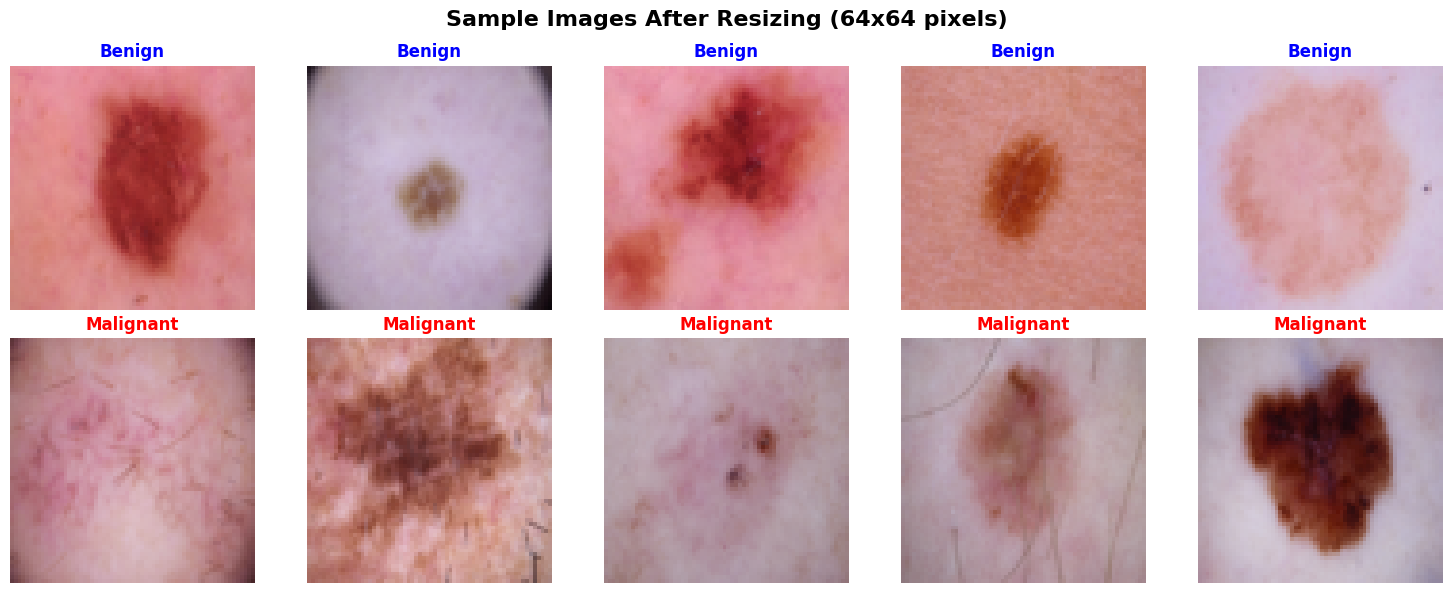

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Let's visualize a few images from the training set after they were resized to 64x64
# We use X_train (before scaling) and reshape the flattened 12,288 length array back to 64x64x3
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images After Resizing (64x64 pixels)', fontsize=16, fontweight='bold')

# Pick 5 Benign and 5 Malignant samples
benign_idx = np.where(y_train == 0)[0][:5]
malignant_idx = np.where(y_train == 1)[0][:5]
sample_idx = np.concatenate([benign_idx, malignant_idx])

for i, ax in enumerate(axes.flatten()):
    idx = sample_idx[i]
    # Reshape the flattened 1D array back into a viewable image
    img = X_train[idx].reshape(64, 64, 3).astype('uint8')
    ax.imshow(img)
    
    label = "Malignant" if y_train[idx] == 1 else "Benign"
    ax.set_title(label, fontweight='bold', color='red' if label == "Malignant" else 'blue')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Apply SMOTE to Training Data Only

In [6]:
print(f"Before SMOTE - Malignant: {sum(y_train==1)}, Benign: {sum(y_train==0)}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE  - Malignant: {sum(y_train_smote==1)}, Benign: {sum(y_train_smote==0)}")

Before SMOTE - Malignant: 1368, Benign: 5642
After SMOTE  - Malignant: 5642, Benign: 5642


## 4. Train & Evaluate Models

In [7]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import time

# ---------------------------------------------------------
# 1. DEFINE MODELS
# ---------------------------------------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RBF SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# ---------------------------------------------------------
# 2. APPLY PCA (For SVM only)
# ---------------------------------------------------------
print("Applying PCA to reduce 12,288 dimensions down to 100 for the SVM...")
pca = PCA(n_components=100, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_train_smote_pca = pca.transform(X_train_smote)

print("PCA complete. Starting training loop...\n")

# ---------------------------------------------------------
# 3. EVALUATION FUNCTION
# ---------------------------------------------------------
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

# ---------------------------------------------------------
# 4. TRAINING LOOP
# ---------------------------------------------------------
results = []
trained_models = {} # Save models for confusion matrix plotting later

for name, model in models.items():
    
    # Apply PCA only to the SVM, use raw scaled data for others
    if name == 'RBF SVM':
        print(f"[{name}] Using PCA compressed features (100 dims)")
        train_X = X_train_pca
        test_X  = X_test_pca
        smote_X = X_train_smote_pca
    else:
        print(f"[{name}] Using Raw features (12,288 dims)")
        train_X = X_train_scaled
        test_X  = X_test_scaled
        smote_X = X_train_smote
        
    print(f"Training {name} on Imbalanced Data...")
    start_time = time.time()
    model.fit(train_X, y_train)
    res_imb = evaluate_model(model, test_X, y_test)
    res_imb['Model'] = name
    res_imb['Dataset'] = 'Imbalanced'
    results.append(res_imb)
    print(f"  -> Finished in {time.time() - start_time:.1f}s")
    
    print(f"Training {name} on SMOTE Data...")
    start_time = time.time()
    model.fit(smote_X, y_train_smote)
    res_smote = evaluate_model(model, test_X, y_test)
    res_smote['Model'] = name
    res_smote['Dataset'] = 'SMOTE'
    results.append(res_smote)
    print(f"  -> Finished in {time.time() - start_time:.1f}s\n")
    
    # Save the SMOTE version of the model to plot confusion matrices later
    trained_models[name] = model

results_df = pd.DataFrame(results)

Applying PCA to reduce 12,288 dimensions down to 100 for the SVM...
PCA complete. Starting training loop...

[Logistic Regression] Using Raw features (12,288 dims)
Training Logistic Regression on Imbalanced Data...
  -> Finished in 168.2s
Training Logistic Regression on SMOTE Data...
  -> Finished in 214.7s

[KNN] Using Raw features (12,288 dims)
Training KNN on Imbalanced Data...
  -> Finished in 3.0s
Training KNN on SMOTE Data...
  -> Finished in 4.8s

[RBF SVM] Using PCA compressed features (100 dims)
Training RBF SVM on Imbalanced Data...
  -> Finished in 7.8s
Training RBF SVM on SMOTE Data...
  -> Finished in 31.5s

[Decision Tree] Using Raw features (12,288 dims)
Training Decision Tree on Imbalanced Data...
  -> Finished in 83.2s
Training Decision Tree on SMOTE Data...
  -> Finished in 193.5s



## 5. Comparison & Results

In [8]:
import IPython.display as display

print("="*60)
print(" PERFORMANCE METRICS: IMBALANCED DATASET (Baseline)")
print("="*60)
imb_df = results_df[results_df['Dataset'] == 'Imbalanced'].drop(columns=['Dataset']).set_index('Model')
display.display(imb_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']])

print("\n" + "="*60)
print(" PERFORMANCE METRICS: SMOTE BALANCED DATASET")
print("="*60)
smote_df = results_df[results_df['Dataset'] == 'SMOTE'].drop(columns=['Dataset']).set_index('Model')
display.display(smote_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']])

 PERFORMANCE METRICS: IMBALANCED DATASET (Baseline)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.779108,0.422311,0.361775,0.389706,0.690695
KNN,0.811710,0.565789,0.146758,0.233062,0.731316
RBF SVM,0.827678,0.723684,0.187713,0.298103,0.860813
Decision Tree,0.783766,0.444828,0.440273,0.442539,0.653608



 PERFORMANCE METRICS: SMOTE BALANCED DATASET


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.762475,0.388889,0.382253,0.385542,0.690207
KNN,0.709914,0.373002,0.716724,0.490654,0.779847
RBF SVM,0.749168,0.416996,0.720137,0.528160,0.832807
Decision Tree,0.727212,0.354839,0.488055,0.410920,0.636589


## 6. Confusion Matrices

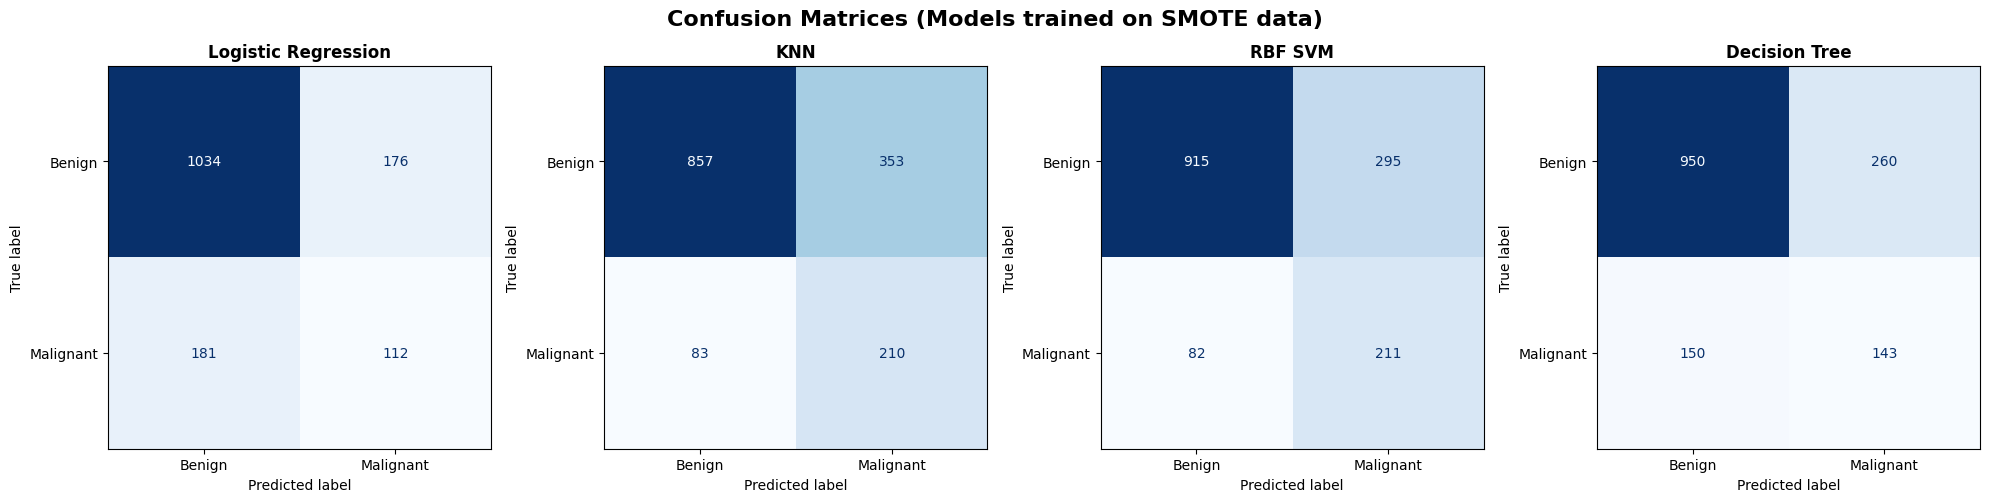

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices (Models trained on SMOTE data)', fontsize=16, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    # Select the correct test data (PCA for SVM, Raw for others)
    test_X = X_test_pca if name == 'RBF SVM' else X_test_scaled
    
    y_pred = model.predict(test_X)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold')
    ax.grid(False) # Turn off the seaborn grid lines for clean matrices

plt.tight_layout()
plt.show()

## 7. Visual Performance Comparison

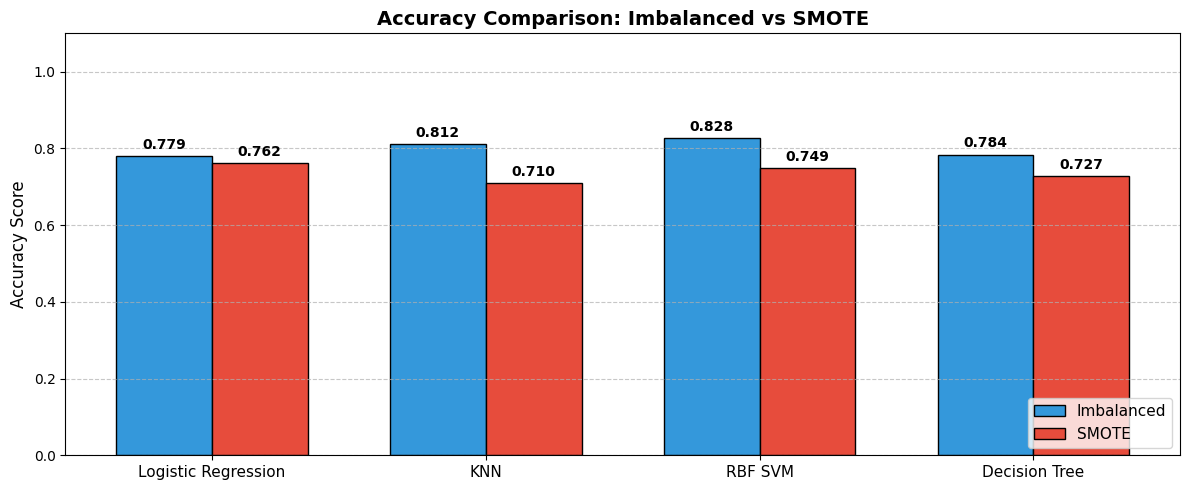

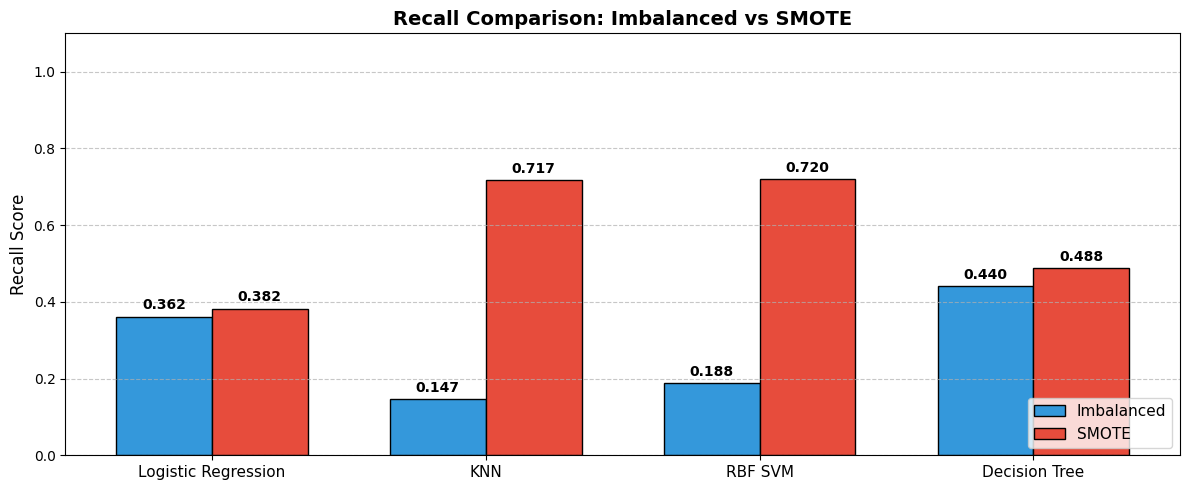

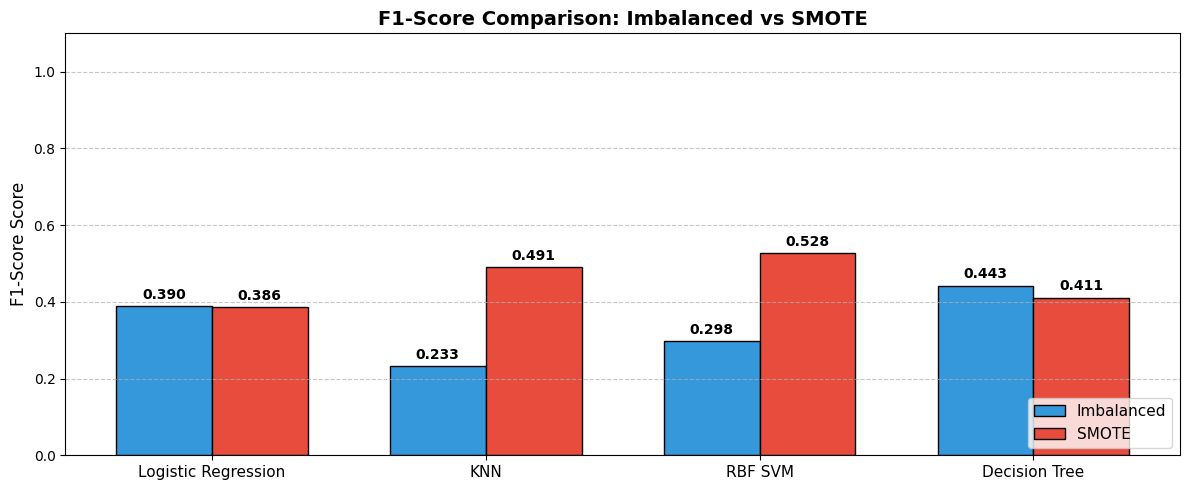

In [10]:
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['Accuracy', 'Recall', 'F1-Score']
models_list = list(models.keys())
x = np.arange(len(models_list))
width = 0.35

for metric in metrics_to_plot:
    imb_scores = [imb_df.loc[m, metric] for m in models_list]
    smote_scores = [smote_df.loc[m, metric] for m in models_list]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    rects1 = ax.bar(x - width/2, imb_scores, width, label='Imbalanced', color='#3498db', edgecolor='black')
    rects2 = ax.bar(x + width/2, smote_scores, width, label='SMOTE', color='#e74c3c', edgecolor='black')
    
    ax.set_ylabel(metric + ' Score', fontsize=12)
    ax.set_title(f'{metric} Comparison: Imbalanced vs SMOTE', fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, fontsize=11)
    ax.legend(loc='lower right', fontsize=11)
    
    # Add text labels on top of bars
    ax.bar_label(rects1, padding=3, fmt='%.3f', fontweight='bold')
    ax.bar_label(rects2, padding=3, fmt='%.3f', fontweight='bold')
    
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 8. Visual of SMOTE DATA

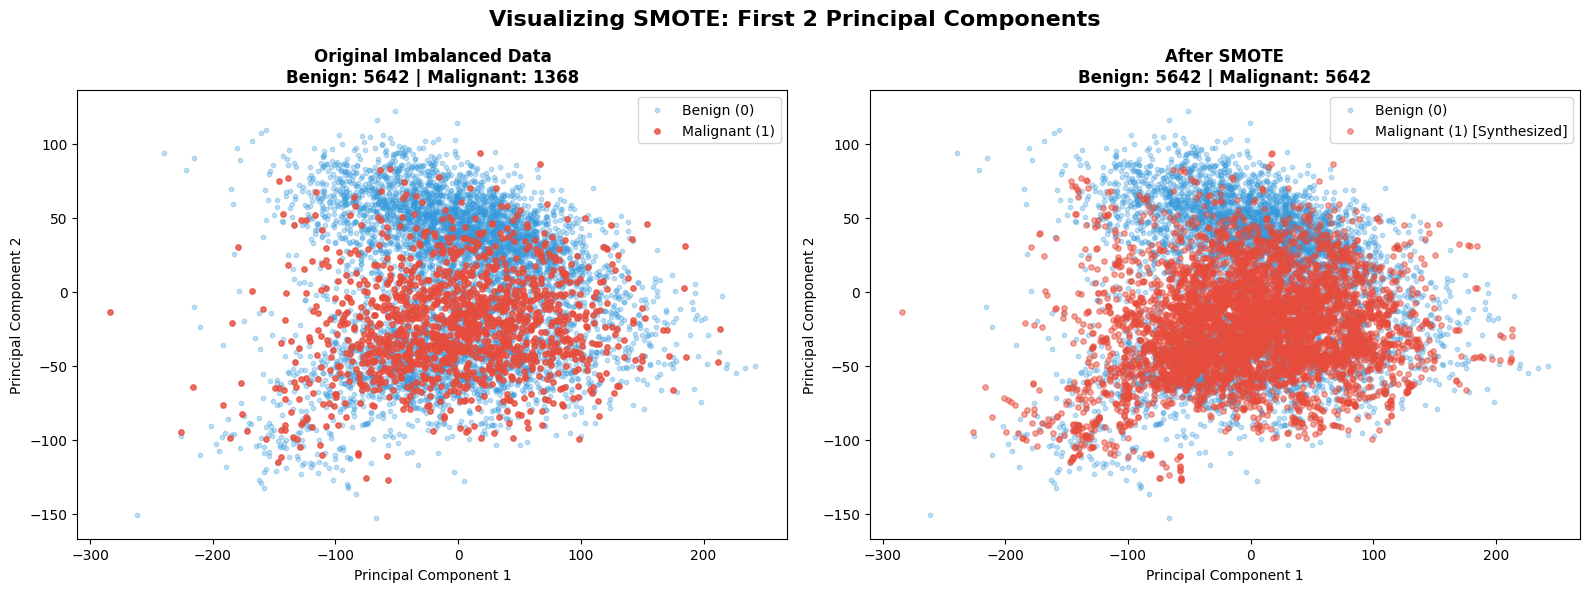

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualizing SMOTE: First 2 Principal Components', fontsize=16, fontweight='bold')

# Plot Imbalanced
axes[0].scatter(X_train_pca[y_train==0, 0], X_train_pca[y_train==0, 1], alpha=0.3, label='Benign (0)', color='#3498db', s=10)
axes[0].scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1], alpha=0.8, label='Malignant (1)', color='#e74c3c', s=15)
axes[0].set_title(f'Original Imbalanced Data\nBenign: {sum(y_train==0)} | Malignant: {sum(y_train==1)}', fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend()

# Plot SMOTE
axes[1].scatter(X_train_smote_pca[y_train_smote==0, 0], X_train_smote_pca[y_train_smote==0, 1], alpha=0.3, label='Benign (0)', color='#3498db', s=10)
axes[1].scatter(X_train_smote_pca[y_train_smote==1, 0], X_train_smote_pca[y_train_smote==1, 1], alpha=0.5, label='Malignant (1) [Synthesized]', color='#e74c3c', s=15)
axes[1].set_title(f'After SMOTE\nBenign: {sum(y_train_smote==0)} | Malignant: {sum(y_train_smote==1)}', fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend()

plt.tight_layout()
plt.show()

### How to Interpret This Visualization

**1. The Original Imbalanced Data (Left Graph)**
*   **Blue Points (Benign):** Notice how there is a massive, dense cloud of blue points. Because there are over 5,600 Benign images, they completely dominate the mathematical feature space.
*   **Red Points (Malignant):** There are only ~1,300 Malignant images. They are scattered and completely drowned out by the blue points. If a Machine Learning model looks at this, it will naturally assume almost everything is "Blue" because it's statistically the safest bet. This is exactly why the models initially failed to detect cancer (Recall ~0.0%).

**2. After SMOTE (Right Graph)**
*   **Synthesized Red Points:** SMOTE (Synthetic Minority Over-sampling Technique) didn't just copy and paste the old red images. Instead, it looked at the existing red points, drew mathematical lines between them, and created **brand new, synthetic** red points along those lines!
*   **The Result:** The red cloud is now exactly as dense and voluminous as the blue cloud (5,642 points each). When the Machine Learning models look at this new, balanced space, they are forced to treat the classes equally. They can finally draw fair mathematical boundaries between Benign and Malignant, completely fixing the model's "blind spot" for cancer.